In [1]:
import glob
from tqdm.auto import tqdm
import numpy as np
import os
import json

from semantic_state_estimator.constants import (
    RENDERS_DIR,
    TRUE_STATES_DIR,
    PROCESSED_DIR
)

DATA_DIR = 'examples/groceriesworld_home/data_dir'
seeds = os.listdir(os.path.join(DATA_DIR, PROCESSED_DIR))

all_renders = {}
gts = {}
preds = {seed: {} for seed in seeds}
for renders_file in tqdm(glob.glob(os.path.join(DATA_DIR, RENDERS_DIR, '*.npz'))):
    dp_name = os.path.splitext(os.path.basename(renders_file))[0]
    
    all_renders[dp_name] = np.load(renders_file)
    
    with open(os.path.join(DATA_DIR, TRUE_STATES_DIR, dp_name + '.json'), 'r') as f:
        gts[dp_name] = json.load(f)

    for seed in seeds:
        with open(os.path.join(DATA_DIR, PROCESSED_DIR, str(seed), dp_name + '.json'), 'r') as f:
            preds[seed][dp_name] = json.load(f)

  0%|          | 0/2000 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: 'examples/groceriesworld_home/data_dir/processed/llama-llava-iter-images-72B/data_point_1657.json'

In [2]:
import numpy as np


def squash_predicate(dp_dicts):
    out = []
    dp_dict_keys_sorted = sorted(dp_dicts.keys())
    predicates = sorted(next(iter(dp_dicts.values())))
    for dp_key in dp_dict_keys_sorted:
        dp_arr = []
        for predicate in predicates:
            dp_arr.append(dp_dicts[dp_key][predicate])
        out.append(dp_arr)

    return np.array(out)

In [3]:
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, roc_curve, accuracy_score, confusion_matrix


def npv_spcificity_curve(y, y_score, thresholds):
    npv = []
    specificity = []
    for t in thresholds:
        tn, fp, fn, tp = confusion_matrix(y, y_score > t).ravel()
        npv.append(tn / (tn + fn))
        specificity.append(tn / (tn + fp))

    return np.array(npv), np.array(specificity)


def collect_metrics(ground_truths, predicted_scores):
    # sqash to array format
    y = squash_predicate(ground_truths)
    y_score = squash_predicate(predicted_scores)

    # map predicates in alphabetical order for consistency
    pred_to_idx = {pred: i for i, pred in enumerate(sorted(next(iter(ground_truths.values()))))}

    # instantiate output containters
    accuracy = {}
    average_precision = {}
    precision = {}
    recall = {}
    thresholds = {}
    npv = {}
    specificity = {}
    fpr = {}
    tpr = {}
    auc = {}

    # iterate predicates
    for pred, i in tqdm(pred_to_idx.items()):
        # get precision and recall curves
        precision[pred], recall[pred], thresholds[pred] = precision_recall_curve(y[:, i], y_score[:, i])
        thresholds[pred] = np.concatenate([thresholds[pred], [1]])  # last threshold is omitted. add it back

        # npv[pred], specificity[pred] = npv_spcificity_curve(y[:, i], y_score[:, i], thresholds[pred])

        # get ROC curve values
        fpr[pred], tpr[pred], _ = roc_curve(y[:, i], y_score[:, i])

        # get Accuracy, AP and ROC-AUC scores
        accuracy[pred] = accuracy_score(y[:, i], y_score[:, i] > 0.5)
        average_precision[pred] = average_precision_score(y[:, i], y_score[:, i])
        auc[pred] = roc_auc_score(y[:, i], y_score[:, i])

    # get all-class AP and ROC-AUC scores
    accuracy['macro'] = np.mean(list(accuracy.values()))
    average_precision['macro'] = average_precision_score(y, y_score, average='macro')
    average_precision['micro'] = average_precision_score(y, y_score, average='micro')
    auc['macro'] = roc_auc_score(y, y_score, average='macro')
    auc['micro'] = roc_auc_score(y, y_score, average='micro')

    return (
        accuracy,
        average_precision,
        precision,
        recall,
        thresholds,
        npv,
        specificity,
        fpr,
        tpr,
        auc
    )

# (
#     accuracy,
#     average_precision,
#     precision,
#     recall,
#     thresholds,
#     npv,
#     specificity,
#     fpr,
#     tpr,
#     auc
# ) = collect_metrics(gts, preds['default-llama-llava-with-suction-grip-instruct'])
# ) = collect_metrics(gts, preds['default-llama-llava'])

In [ ]:
average_precision_with_grip = collect_metrics(gts, preds['default-llama-llava-with-suction-grip-instruct'])[1]

In [ ]:
average_precision_no_grip = collect_metrics(gts, preds['default-llama-llava'])[1]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

width=0.25
heights1 = average_precision_no_grip.values()
heights2 = average_precision_with_grip.values()
bars = average_precision_with_grip.keys()
y_pos = range(len(bars))
y_pos2 = [p + width for p in y_pos]
plt.bar(y_pos, heights1, width=width, label='no grip instruct')
plt.bar(y_pos2, heights2, width=width, label='with grip instruct')
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5));

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()


heights = accuracy.values()
bars = accuracy.keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
heights = average_precision.values()
bars = average_precision.keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
heights = average_precision.values()
bars = average_precision.keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
heights = auc.values()
bars = auc.keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'precisions and recall: {predicate}')
    plt.plot(thresholds[predicate], precision[predicate], label='precision')
    plt.plot(thresholds[predicate], recall[predicate], label='recall')
    plt.legend()
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'PRC: {predicate}')
    plt.plot(recall[predicate], precision[predicate])
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'npv and specificity: {predicate}')
    plt.plot(thresholds[predicate], npv[predicate], label='npv')
    plt.plot(thresholds[predicate], specificity[predicate], label='specificity')
    plt.legend()
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'NSC: {predicate}')
    plt.plot(specificity[predicate], npv[predicate])
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'ROC: {predicate}')
    plt.plot(fpr[predicate], tpr[predicate])
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.show()

In [4]:
from semantic_state_estimator.semantic_state_estimator import SemanticStateEstimatorWithLLaMA
from PIL import Image
from llava.constants import DEFAULT_IMAGE_TOKEN

EXAMPLE = 'groceriesworld_home'
LLAMA_ID = "meta-llama/Meta-Llama-3-70B-Instruct"
LLAVA_ID = "lmms-lab/llava-onevision-qwen2-72b-ov"

addtional_instructions=f"The robot's gripper is a suction gripper. If an item appears stuck to the robot end-effector, this means that the robot is currently gripping that item and that the gripper is not empty. Otherwise, the gripper is considerred empty. Here is an example of the robot gripping the milk carton: {DEFAULT_IMAGE_TOKEN}"
additional_images = [Image.open(f'examples/{EXAMPLE}/grip-milk-full.png')]

se = SemanticStateEstimatorWithLLaMA(
    domain=f'examples/{EXAMPLE}/domain.pddl',
    problem=f'examples/{EXAMPLE}/problem.pddl',
    nl_converter_model_id=LLAMA_ID,
    vqa_model_id=LLAVA_ID,
    additional_instructions=addtional_instructions,
    additional_images=additional_images
)

/home/gazran/miniforge3/envs/my_sse/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


predicate queries loaded from cache
Loaded LLaVA model: lmms-lab/llava-onevision-qwen2-72b-ov


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
You are using a model of type llava to instantiate a model of type llava_qwen. This is not supported for all configurations of models and can yield errors.


Loading vision tower: google/siglip-so400m-patch14-384


Loading checkpoint shards:   0%|          | 0/31 [00:00<?, ?it/s]

Model Class: LlavaQwenForCausalLM


In [ ]:
from semantic_state_estimator.utils.misc import remove_from_gpu_memory
remove_from_gpu_memory(se)

In [ ]:
se.vqa_model.clear_system_cache()

In [5]:
# PREDICATE = 'on-table(milk-carton,wood-table)'
# PREDICATE = 'robot-gripper-empty()'
PREDICATE = 'robot-gripping(milk-carton)'

dps = []
for dp_name in gts.keys():
    if gts[dp_name][PREDICATE] != (preds['default-llama-llava'][dp_name][PREDICATE] > 0.5):
    # if gts[dp_name][PREDICATE] == True:
        dps.append(dp_name)
len(dps)

141

True


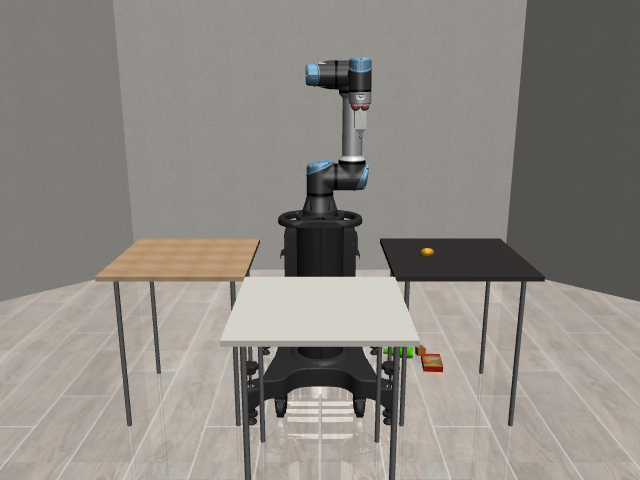

In [6]:
from PIL import Image

dp_name = np.random.choice(dps)

img = Image.fromarray(
    all_renders[dp_name]['frontview']
)
print(gts[dp_name][PREDICATE])
img

In [7]:
se.estimate_state([
    Image.fromarray(img_arr)
    for img_arr in list(all_renders[dp_name].values())[:3]
])
# se.estimate_state([
#     Image.fromarray(all_renders[dp_name]['rightsideview'])
# ])

OutOfMemoryError: CUDA out of memory. Tried to allocate 834.00 MiB. GPU 0 has a total capacty of 44.45 GiB of which 810.69 MiB is free. Including non-PyTorch memory, this process has 43.65 GiB memory in use. Of the allocated memory 43.02 GiB is allocated by PyTorch, and 324.75 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF